# Ark+ 3D — MedMNIST 3D (3 datasets, 10 epochs)

Replicates the **Ark+** teacher-student pretraining framework  
([jlianglab/Ark](https://github.com/jlianglab/Ark/tree/main/Ark_Plus))  
adapted for **3D volumetric** MedMNIST datasets.

| Component | 2D version (existing) | 3D version (this notebook) |
|---|---|---|
| Backbone | Swin-Base 2D (timm) | Lightweight 3D ResNet (custom) |
| Input | (B, 3, 64, 64) | (B, 1, 28, 28, 28) |
| Datasets | 12 × 2D MedMNIST | 3 × 3D MedMNIST (→ 6 later) |
| Loss | (1-coff)·CE + coff·MSE(feat) | same |
| Teacher update | EMA per dataset sub-epoch | same |

**First run:** OrganMNIST3D (11-class) · NoduleMNIST3D (2-class) · FractureMNIST3D (3-class)  
**Hardware target:** RTX 4060 · 8 GB VRAM · 16 GB RAM

In [10]:
import torch
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU  :', torch.cuda.get_device_name(0))
    print('VRAM :', round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 1), 'GB')
else:
    print('WARNING: No CUDA — training will be very slow on CPU')

CUDA available: True
GPU  : NVIDIA GeForce RTX 4060
VRAM : 8.0 GB


## 1 — Install / verify dependencies
Run once. Skip if already installed.

In [11]:
import subprocess, sys
pkgs = ['medmnist', 'scikit-learn', 'matplotlib']
for pkg in pkgs:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
print('All packages ready.')

All packages ready.


## 2 — 3D Dataset Wrapper

Each `__getitem__` returns **(view1, view2, label)**:  
- `view1` / `view2` — independently augmented tensors `(1, 28, 28, 28)` — student / teacher views  
- `label` — long integer class index  

**Augmentation (train only):** random axis flips + mild intensity jitter. No extra libraries needed.

In [12]:
%%writefile medmnist3d_dataloader.py

import torch
from torch.utils.data import Dataset
import medmnist
import numpy as np


# ─── Registry of all 6 MedMNIST 3D datasets ──────────────────────────────────
DATASET_MAP_3D = {
    'OrganMNIST3D':    medmnist.OrganMNIST3D,
    'NoduleMNIST3D':   medmnist.NoduleMNIST3D,
    'AdrenalMNIST3D':  medmnist.AdrenalMNIST3D,
    'FractureMNIST3D': medmnist.FractureMNIST3D,
    'VesselMNIST3D':   medmnist.VesselMNIST3D,
    'SynapseMNIST3D':  medmnist.SynapseMNIST3D,
}

NUM_CLASSES_MAP_3D = {
    'OrganMNIST3D':    11,
    'NoduleMNIST3D':    2,
    'AdrenalMNIST3D':   2,
    'FractureMNIST3D':  3,
    'VesselMNIST3D':    2,
    'SynapseMNIST3D':   2,
}

TASK_MAP_3D = {name: 'multi-class classification' for name in DATASET_MAP_3D}


class Augment3D:
    """Stochastic 3D augmentation for teacher-student dual-view training."""

    def __init__(self, training=True):
        self.training = training

    def __call__(self, vol):
        """vol: np.float32 (D,H,W) in [0,1]  →  torch (1,D,H,W)"""
        if self.training:
            for ax in range(3):
                if np.random.rand() > 0.5:
                    vol = np.flip(vol, ax).copy()
            scale = np.random.uniform(0.85, 1.15)
            shift = np.random.uniform(-0.05, 0.05)
            vol = np.clip(vol * scale + shift, 0.0, 1.0)
        return torch.tensor(vol[None], dtype=torch.float32)


class MedMNIST3DWrapper(Dataset):
    """
    Wraps any MedMNIST 3D dataset.
    Returns (view1, view2, label) — dual-view for teacher-student training.
    """

    def __init__(self, dataset_name, split='train'):
        assert dataset_name in DATASET_MAP_3D, (
            f"Unknown 3D dataset: '{dataset_name}'. "
            f"Choose from {list(DATASET_MAP_3D)}"
        )
        self.dataset_name = dataset_name
        self.num_classes  = NUM_CLASSES_MAP_3D[dataset_name]
        self.task_type    = TASK_MAP_3D[dataset_name]

        raw = DATASET_MAP_3D[dataset_name](split=split, download=True)
        self.imgs   = raw.imgs.astype(np.float32) / 255.0  # (N,28,28,28) in [0,1]
        self.labels = raw.labels.squeeze().astype(np.int64)  # (N,)
        self.aug = Augment3D(training=(split == 'train'))

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):
        vol   = self.imgs[idx]           # (28,28,28)
        label = int(self.labels[idx])
        v1    = self.aug(vol)            # student view
        v2    = self.aug(vol)            # teacher view
        return v1, v2, torch.tensor(label, dtype=torch.long)


Overwriting medmnist3d_dataloader.py


## 3 — Ark+ 3D Model

### Architecture
```
Input  (B, 1, 28, 28, 28)
  └─ Conv3d(1→32) + BN + ReLU          → (B, 32, 28, 28, 28)
  └─ ResBlock3D(32→64,  stride=2)       → (B, 64, 14, 14, 14)
  └─ ResBlock3D(64→128, stride=2)       → (B,128,  7,  7,  7)
  └─ ResBlock3D(128→256,stride=2)       → (B,256,  4,  4,  4)
  └─ AdaptiveAvgPool3d(1) + Flatten     → (B, 256)
                 │
        ┌────────┴────────┐
   projector           omni_heads[i]
  Linear→ReLU→Linear   Linear(256→nᵢ)
   (B, feat_dim)         (B, num_classes)
       ↑                       ↑
 EMA MSE loss           CE loss
```

~1.2 M parameters — fits comfortably in 8 GB VRAM.

In [16]:
%%writefile train_ark_3d_3datasets.py

import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import DataLoader
from sklearn.metrics import roc_auc_score
from medmnist3d_dataloader import (
    MedMNIST3DWrapper, NUM_CLASSES_MAP_3D, TASK_MAP_3D
)
import os
import time

# ─── CONFIG ───────────────────────────────────────────────────────────────────
EXPERIMENT   = 'ark_3d_3datasets'
DATASETS     = ['OrganMNIST3D', 'NoduleMNIST3D', 'FractureMNIST3D']
BATCH_SIZE   = 16
EPOCHS       = 200
LR           = 1e-3
MOMENTUM_EMA = 0.9
FEAT_DIM     = 128
USE_AMP      = True
DEVICE       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SAVE_DIR     = os.path.join('./outputs', EXPERIMENT)
os.makedirs(SAVE_DIR, exist_ok=True)
# ──────────────────────────────────────────────────────────────────────────────


# ─── 3D BACKBONE ──────────────────────────────────────────────────────────────
class ResBlock3D(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv1 = nn.Conv3d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm3d(out_ch)
        self.conv2 = nn.Conv3d(out_ch, out_ch, 3, stride=1, padding=1, bias=False)
        self.bn2   = nn.BatchNorm3d(out_ch)
        self.relu  = nn.ReLU(inplace=True)
        self.skip  = (
            nn.Sequential(
                nn.Conv3d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm3d(out_ch),
            )
            if (stride != 1 or in_ch != out_ch) else nn.Identity()
        )

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return self.relu(out + self.skip(x))


class Ark3D(nn.Module):
    """
    Ark+ teacher-student model for 3D medical volumes.

    forward(x, head_n) → (feat, pred)
        feat : (B, FEAT_DIM)    — drives EMA consistency loss
        pred : (B, num_classes) — drives classification loss

    Training loss (per Ark+ paper):
        loss = (1 - coff) * CE(pred_s, y) + coff * MSE(feat_s, feat_t)
    """

    def __init__(self, num_classes_list, feat_dim=128):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv3d(1, 32, 3, stride=1, padding=1, bias=False),
            nn.BatchNorm3d(32),
            nn.ReLU(inplace=True),
            ResBlock3D(32,  64,  stride=2),
            ResBlock3D(64,  128, stride=2),
            ResBlock3D(128, 256, stride=2),
            nn.AdaptiveAvgPool3d(1),
            nn.Flatten(),
        )
        self.projector = nn.Sequential(
            nn.Linear(256, feat_dim),
            nn.ReLU(inplace=True),
            nn.Linear(feat_dim, feat_dim),
        )
        self.omni_heads = nn.ModuleList(
            [nn.Linear(256, nc) for nc in num_classes_list]
        )

    def forward(self, x, head_n):
        enc  = self.encoder(x)              # (B, 256)
        feat = self.projector(enc)          # (B, feat_dim)
        pred = self.omni_heads[head_n](enc) # (B, num_classes)
        return feat, pred


# ─── UTILITIES ────────────────────────────────────────────────────────────────
def ema_update(student, teacher, momentum):
    with torch.no_grad():
        for s_p, t_p in zip(student.parameters(), teacher.parameters()):
            t_p.data = momentum * t_p.data + (1.0 - momentum) * s_p.data


def compute_auc(y_true, y_pred, num_classes):
    y_true = y_true.numpy().astype(int)
    y_pred = y_pred.numpy()
    y_true_oh = np.eye(num_classes)[y_true]
    aucs = []
    for c in range(num_classes):
        if y_true_oh[:, c].sum() > 0:
            aucs.append(roc_auc_score(y_true_oh[:, c], y_pred[:, c]))
    return float(np.mean(aucs)) if aucs else 0.5


# ─── TRAIN ONE EPOCH FOR ONE DATASET ──────────────────────────────────────────
def train_one_cycle(model, teacher, loader, head_n,
                    optimizer, scaler, epoch, device):
    model.train()
    criterion = nn.CrossEntropyLoss()
    mse_loss  = nn.MSELoss()
    coff = min((epoch / EPOCHS) * 0.1, 0.1)  # ramps 0 → 0.1

    total_loss = total_cls = total_mse = n = 0

    for v1, v2, labels in loader:
        v1, v2, labels = v1.to(device), v2.to(device), labels.to(device)
        optimizer.zero_grad()

        with torch.cuda.amp.autocast(enabled=USE_AMP):
            feat_s, pred_s = model(v1, head_n)
            with torch.no_grad():
                feat_t, _ = teacher(v2, head_n)
            loss_cls   = criterion(pred_s, labels)
            loss_const = mse_loss(feat_s, feat_t)
            loss       = (1.0 - coff) * loss_cls + coff * loss_const

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        total_cls  += loss_cls.item()
        total_mse  += loss_const.item()
        n += 1

    return total_loss / n, total_cls / n, total_mse / n


# ─── VALIDATION ───────────────────────────────────────────────────────────────
def evaluate(model, loader, head_n, num_classes, device):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for v1, _, labels in loader:
            v1 = v1.to(device)
            with torch.cuda.amp.autocast(enabled=USE_AMP):
                _, pred = model(v1, head_n)
            all_preds.append(torch.softmax(pred, dim=1).cpu())
            all_labels.append(labels.cpu())
    return compute_auc(
        torch.cat(all_labels), torch.cat(all_preds), num_classes
    )


# ─── MAIN ─────────────────────────────────────────────────────────────────────
def main():
    print('=' * 60)
    print(f'EXPERIMENT : {EXPERIMENT}')
    print(f'DATASETS   : {DATASETS}')
    print(f'BATCH_SIZE : {BATCH_SIZE}')
    print(f'EPOCHS     : {EPOCHS}')
    print(f'LR         : {LR}')
    print(f'EMA mom    : {MOMENTUM_EMA}')
    print(f'DEVICE     : {DEVICE}')
    print(f'AMP        : {USE_AMP}')
    print('=' * 60)

    # ── Dataloaders ────────────────────────────────────────────────────────────
    num_classes_list = [NUM_CLASSES_MAP_3D[d] for d in DATASETS]
    train_loaders, val_loaders, test_loaders = [], [], []

    print('\nDownloading & building 3D dataloaders...')
    for name in DATASETS:
        tr = MedMNIST3DWrapper(name, split='train')
        va = MedMNIST3DWrapper(name, split='val')
        te = MedMNIST3DWrapper(name, split='test')
        train_loaders.append(DataLoader(tr, batch_size=BATCH_SIZE,
                                        shuffle=True,  num_workers=0, pin_memory=True))
        val_loaders  .append(DataLoader(va, batch_size=BATCH_SIZE,
                                        shuffle=False, num_workers=0, pin_memory=True))
        test_loaders .append(DataLoader(te, batch_size=BATCH_SIZE,
                                        shuffle=False, num_workers=0, pin_memory=True))
        print(f'  {name:20s}  train={len(tr):5d}  val={len(va):5d}  test={len(te):5d}'
              f'  classes={NUM_CLASSES_MAP_3D[name]}')

    # ── Models ─────────────────────────────────────────────────────────────────
    print('\nBuilding Ark3D student + teacher...')
    model   = Ark3D(num_classes_list, feat_dim=FEAT_DIM).to(DEVICE)
    teacher = Ark3D(num_classes_list, feat_dim=FEAT_DIM).to(DEVICE)
    teacher.load_state_dict(model.state_dict())
    for p in teacher.parameters():
        p.requires_grad = False

    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'  Trainable params : {n_params / 1e6:.2f} M')
    print(f'  Head sizes       : {num_classes_list}')

    optimizer = torch.optim.SGD(
        model.parameters(), lr=LR, momentum=0.9, weight_decay=1e-4
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=EPOCHS
    )
    scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

    # ── Logging setup ──────────────────────────────────────────────────────────
    log_path = os.path.join(SAVE_DIR, 'train_log.txt')
    history  = {
        'epoch':       [],
        'avg_auc':     [],
        'per_dataset': {d: [] for d in DATASETS},
    }
    with open(log_path, 'w') as f:
        f.write(f'Experiment : {EXPERIMENT}\n')
        f.write(f'Datasets   : {DATASETS}\n')
        f.write(f'Batch size : {BATCH_SIZE}  Epochs : {EPOCHS}\n\n')

    # ── Training loop ──────────────────────────────────────────────────────────
    best_avg_auc = 0.0
    print('\nStarting Ark+ 3D cyclic training...\n')

    for epoch in range(EPOCHS):
        t0 = time.time()
        print(f"\n{'='*60}")
        print(f'Epoch {epoch + 1}/{EPOCHS}')
        print(f"{'='*60}")

        # One full pass through each dataset (cyclic, mirrors Ark+)
        for i, name in enumerate(DATASETS):
            loss, cls_l, mse_l = train_one_cycle(
                model, teacher, train_loaders[i], i,
                optimizer, scaler, epoch, DEVICE
            )
            ema_update(model, teacher, MOMENTUM_EMA)
            print(f'  [{name:20s}]  '
                  f'loss={loss:.4f}  cls={cls_l:.4f}  mse={mse_l:.4f}')

        scheduler.step()

        # Validation (always run on teacher)
        print('\n  Validation AUC (teacher):')
        auc_list = []
        for i, name in enumerate(DATASETS):
            auc = evaluate(
                teacher, val_loaders[i], i, num_classes_list[i], DEVICE
            )
            auc_list.append(auc)
            history['per_dataset'][name].append(auc)
            print(f'    {name:20s}: {auc:.4f}')

        avg_auc    = float(np.mean(auc_list))
        epoch_secs = time.time() - t0
        print(f"    {'Average':20s}: {avg_auc:.4f}")
        print(f'  Epoch time : {epoch_secs / 60:.1f} min')

        history['epoch'].append(epoch + 1)
        history['avg_auc'].append(avg_auc)

        with open(log_path, 'a') as f:
            f.write(f'Epoch {epoch+1}: avg_auc={avg_auc:.4f}  '
                    f'time={epoch_secs/60:.1f}min\n')
            for name, auc in zip(DATASETS, auc_list):
                f.write(f'  {name}: {auc:.4f}\n')
            f.write('\n')

        if avg_auc > best_avg_auc:
            best_avg_auc = avg_auc
            torch.save({
                'epoch':      epoch,
                'state_dict': model.state_dict(),
                'teacher':    teacher.state_dict(),
                'optimizer':  optimizer.state_dict(),
                'avg_auc':    avg_auc,
                'auc_list':   auc_list,
                'datasets':   DATASETS,
            }, os.path.join(SAVE_DIR, 'best_model.pth'))
            print(f'  ★ New best saved  AUC={avg_auc:.4f}')

    # ── Final test ─────────────────────────────────────────────────────────────
    print(f"\n{'='*60}\nFINAL TEST EVALUATION\n{'='*60}")
    ckpt = torch.load(
        os.path.join(SAVE_DIR, 'best_model.pth'), weights_only=False
    )
    teacher.load_state_dict(ckpt['teacher'])
    print(f"Loaded best model from epoch {ckpt['epoch'] + 1}\n")

    test_aucs = []
    for i, name in enumerate(DATASETS):
        auc = evaluate(
            teacher, test_loaders[i], i, num_classes_list[i], DEVICE
        )
        test_aucs.append(auc)
        print(f'  {name:20s}  Test AUC: {auc:.4f}')

    mean_auc = float(np.mean(test_aucs))
    print(f'\n  Mean Test AUC : {mean_auc:.4f}')
    print(f'  Best Val  AUC : {best_avg_auc:.4f}')

    with open(log_path, 'a') as f:
        f.write('\nFINAL TEST:\n')
        for name, auc in zip(DATASETS, test_aucs):
            f.write(f'  {name}: {auc:.4f}\n')
        f.write(f'Mean Test AUC: {mean_auc:.4f}\n')

    print(f'\nLog saved → {log_path}')
    print('=' * 60)
    return history, test_aucs


history, test_aucs = main()


Overwriting train_ark_3d_3datasets.py


## 4 — Run training

This cell writes both `.py` files and then executes the training.  
Expected time on RTX 4060: **~3-6 min per epoch** (10 epochs ≈ 30-60 min total).

Watch for:
- `cls` loss decreasing per dataset → model is learning labels  
- `mse` loss decreasing → student/teacher representations aligning  
- Validation AUC increasing each epoch

In [17]:
exec(open('train_ark_3d_3datasets.py').read())

EXPERIMENT : ark_3d_3datasets
DATASETS   : ['OrganMNIST3D', 'NoduleMNIST3D', 'FractureMNIST3D']
BATCH_SIZE : 16
EPOCHS     : 200
LR         : 0.001
EMA mom    : 0.9
DEVICE     : cuda
AMP        : True

  OrganMNIST3D          train=  971  val=  161  test=  610  classes=11
  NoduleMNIST3D         train= 1158  val=  165  test=  310  classes=2
  FractureMNIST3D       train= 1027  val=  103  test=  240  classes=3

Building Ark3D student + teacher...
  Trainable params : 3.58 M
  Head sizes       : [11, 2, 3]

Starting Ark+ 3D cyclic training...


Epoch 1/200


<string>:208: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
<string>:123: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


  [OrganMNIST3D        ]  loss=1.9678  cls=1.9678  mse=0.0045
  [NoduleMNIST3D       ]  loss=0.5181  cls=0.5181  mse=0.0049
  [FractureMNIST3D     ]  loss=1.0149  cls=1.0149  mse=0.0023

  Validation AUC (teacher):
    OrganMNIST3D        : 0.6486
    NoduleMNIST3D       : 0.4994
    FractureMNIST3D     : 0.5804
    Average             : 0.5761
  Epoch time : 0.1 min
  â˜… New best saved  AUC=0.5761

Epoch 2/200


<string>:150: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
<string>:150: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
<string>:150: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
<string>:123: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


  [OrganMNIST3D        ]  loss=1.5419  cls=1.5424  mse=0.5807
  [NoduleMNIST3D       ]  loss=0.4809  cls=0.4811  mse=0.1963
  [FractureMNIST3D     ]  loss=0.9935  cls=0.9940  mse=0.0035

  Validation AUC (teacher):
    OrganMNIST3D        : 0.6190
    NoduleMNIST3D       : 0.5079
    FractureMNIST3D     : 0.6180
    Average             : 0.5816
  Epoch time : 0.1 min
  â˜… New best saved  AUC=0.5816

Epoch 3/200


...

  [OrganMNIST3D        ]  loss=38.4554  cls=1.8028  mse=1983.0254
  [NoduleMNIST3D       ]  loss=8.3642  cls=0.5013  mse=425.5257
  [FractureMNIST3D     ]  loss=6.1656  cls=1.0050  mse=279.9587

  Validation AUC (teacher):
    OrganMNIST3D        : 0.4874
    NoduleMNIST3D       : 0.4978
    FractureMNIST3D     : 0.5336
    Average             : 0.5063
  Epoch time : 0.1 min

Epoch 39/200


<string>:150: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
<string>:150: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
<string>:150: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
<string>:123: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


  [OrganMNIST3D        ]  loss=646.6116  cls=2.3252  mse=33912.1375
  [NoduleMNIST3D       ]  loss=nan  cls=nan  mse=nan
  [FractureMNIST3D     ]  loss=nan  cls=nan  mse=nan

  Validation AUC (teacher):


<string>:150: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


ValueError: Input contains NaN.

## 5 — Training curves & results

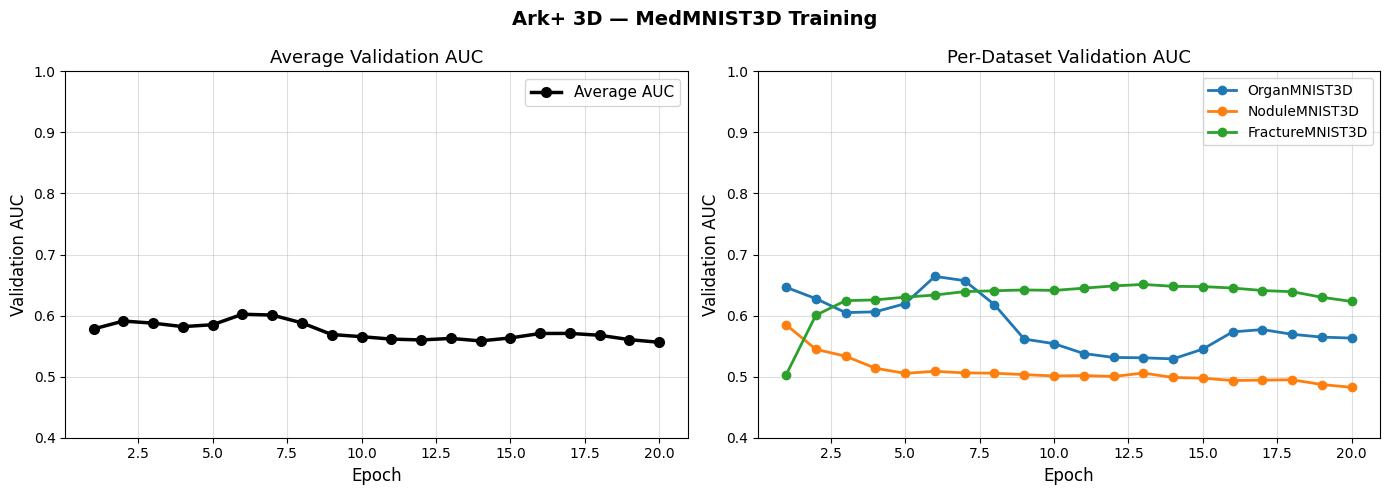

Plot saved → ./outputs/ark_3d_3datasets/training_curves.png

TEST AUC SUMMARY
  OrganMNIST3D        : 0.6549  ████████████████
  NoduleMNIST3D       : 0.4639  ███████████
  FractureMNIST3D     : 0.6355  ███████████████
  Mean                : 0.5848


In [18]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

COLORS = ['tab:blue', 'tab:orange', 'tab:green']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left — average AUC
ax = axes[0]
ax.plot(history['epoch'], history['avg_auc'], 'k-o', linewidth=2.5,
        markersize=7, label='Average AUC')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Validation AUC', fontsize=12)
ax.set_title('Average Validation AUC', fontsize=13)
ax.set_ylim([0.4, 1.0])
ax.legend(fontsize=11)
ax.grid(True, alpha=0.4)

# Right — per-dataset AUC
ax = axes[1]
for name, color in zip(DATASETS, COLORS):
    ax.plot(history['epoch'], history['per_dataset'][name],
            '-o', color=color, linewidth=2, markersize=6, label=name)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Validation AUC', fontsize=12)
ax.set_title('Per-Dataset Validation AUC', fontsize=13)
ax.set_ylim([0.4, 1.0])
ax.legend(fontsize=10)
ax.grid(True, alpha=0.4)

plt.suptitle('Ark+ 3D — MedMNIST3D Training', fontsize=14, fontweight='bold')
plt.tight_layout()
plot_path = f'./outputs/{EXPERIMENT}/training_curves.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Plot saved → {plot_path}')

# Text summary
print('\n' + '='*50)
print('TEST AUC SUMMARY')
print('='*50)
for name, auc, color in zip(DATASETS, test_aucs, COLORS):
    bar = '█' * int(auc * 25)
    print(f'  {name:20s}: {auc:.4f}  {bar}')
print(f"  {'Mean':20s}: {sum(test_aucs)/len(test_aucs):.4f}")

## 6 — Next steps

### Add the remaining 3 datasets (all 6 MedMNIST3D)

In `train_ark_3d_3datasets.py` change:

```python
EXPERIMENT = 'ark_3d_6datasets'
DATASETS   = [
    'OrganMNIST3D',
    'NoduleMNIST3D',
    'FractureMNIST3D',
    'AdrenalMNIST3D',
    'VesselMNIST3D',
    'SynapseMNIST3D',
]
EPOCHS = 20   # more epochs once you confirm training works
```

### Move to the combined 2D + 3D scenario (Step c)

- Separate encoders for 2D (Swin) and 3D (ResNet3D)
- Shared projector dimension for cross-modal EMA consistency
- Train on all 12 × 2D + 6 × 3D datasets jointly

### Tips for longer runs
| Setting | Current | Suggestion for longer run |
|---|---|---|
| `BATCH_SIZE` | 16 | 32 (still fits) |
| `EPOCHS` | 10 | 50–200 |
| `MOMENTUM_EMA` | 0.9 | 0.995 (cosine schedule) |
| Augmentation | flip + jitter | + small random crop/pad |